# 04 — OOF hard-negative quality

This notebook reports the frozen neural-training data contract and its integrity audits.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "reports").exists():
    ROOT = ROOT.parent

def load_json(name):
    return json.loads((ROOT / "reports" / "metrics" / name).read_text())


In [2]:
q = load_json("ranking_data_summary.json")
pd.DataFrame({
    "metric": [
        "sessions", "event rows", "positive/objective rows",
        "hard negatives per positive", "total hard negatives",
        "completed buckets", "false negatives", "fold mismatches",
        "rows with duplicate negatives"
    ],
    "value": [
        q["sessions"], q["event_rows"], q["label_rows"],
        q["hard_negatives_per_positive"], q["total_hard_negatives"],
        q["completed_buckets"], q["false_negative_count"], q["fold_mismatch_count"],
        q["rows_with_duplicate_negatives"]
    ],
})

,metric,value
0,sessions,515702
1,event rows,2096788
2,positive/objective rows,765097
3,hard negatives per positive,64
4,total hard negatives,48966208
5,completed buckets,32
6,false negatives,0
7,fold mismatches,0
8,rows with duplicate negatives,0


In [3]:
folds = pd.DataFrame({
    "fold": range(len(q["fold_session_counts"])),
    "sessions": q["fold_session_counts"],
})
folds

,fold,sessions
0,0,103468
1,1,102891
2,2,102866
3,3,103491
4,4,102986


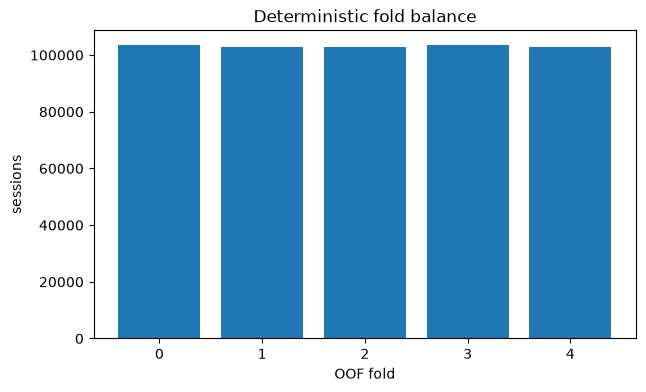

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(folds["fold"].astype(str), folds["sessions"])
ax.set_xlabel("OOF fold")
ax.set_ylabel("sessions")
ax.set_title("Deterministic fold balance")
plt.show()

### Integrity contract

Every hard-negative row was checked against all known future positives for the same session/objective. The frozen corpus contains no future-positive contamination, no fold mismatches, and no duplicate negatives. This is the substrate for the objective-conditioned neural retriever.